# Exploratory Data Analysis: Climate Trends in Kenya

## 1. Title & Objective
Analysis of climate data in Kenya to extract meaningful trends and identify climate volatility in preparation for COP32.

## 2. Data Loading & Date Parsing
- Load `kenya.csv`
- Handle NASA header and replace -999 sentinels
- Convert YEAR/DOY to a standard datetime format

## 3. Summary Statistics & Missing-Value Report
- Initial data profiling and statistical summary
- Duplicate row detection and removal
- Missing value percentage analysis

## 4. Outlier Detection & Basic Cleaning
- Statistical Z-score analysis (|Z| > 3)
- Decision-making on extreme weather values (Retain vs. Cap)
- Forward-fill (ffill) strategy for data continuity

## 5. Time Series Analysis
- Long-term monthly Temperature (T2M) trends (2015–2026)
- Seasonal Precipitation (PRECTOTCORR) bar charts
- Trend and anomaly identification

## 6. Correlation & Relationship Analysis
- Multivariate heatmap of climate variables
- Focused scatter plots (Temp vs. Humidity)
- Identification of strongest climate drivers

## 7. Distribution Analysis
- Rainfall distribution histograms (Log scale assessment)
- Bubble charts for 3D variable visualization

## 8. Key Insights & Conclusion


### Let Us Start

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look professional
%matplotlib inline
sns.set_theme(style="whitegrid")


## 2. Data Loading & Date Parsing

In [3]:
# 1. Load the data
df = pd.read_csv('../data/kenya.csv')

# 2. Add Country column
df['Country'] = 'Kenya'

# 3. Convert YEAR and DOY to a proper Date column
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month
df['Month'] = df['Date'].dt.month

# 5. Preview the result
df[['Date', 'YEAR', 'DOY', 'Month', 'Country']].head()


,Date,YEAR,DOY,Month,Country
0,2015-01-01,2015,1,1,Kenya
1,2015-01-02,2015,2,1,Kenya
2,2015-01-03,2015,3,1,Kenya
3,2015-01-04,2015,4,1,Kenya
4,2015-01-05,2015,5,1,Kenya


In [4]:
# 1. Replacing NASA's -999 sentinel values with actual 'Null' (NaN)
df.replace(-999, np.nan, inplace=True)

# 2. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# 3. If there were duplicates, I would drop them (keeping the first occurrence)
df.drop_duplicates(inplace=True)

# 4. Final check: How many rows do I have now?
print(f"Total rows in Kenya dataset: {df.shape[0]}")


Number of duplicate rows found: 0
Total rows in Kenya dataset: 4108


In [5]:
# Generating descriptive statistics
df.describe()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## 4. Outlier Detection & Basic Cleaning

In [6]:
# 1. Calculating missing values per column
null_counts = df.isna().sum()

# 2. Calculate percentage
null_pct = (null_counts / len(df)) * 100

# 3. Create a summary table
null_report = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_pct})

# 4. Filter only columns that have at least one missing value
print("Missing Value Report for Kenya:")
print(null_report[null_report['Missing Values'] > 0])


Missing Value Report for Kenya:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [7]:
from scipy import stats

# 1. Selecting numeric columns for outlier detection
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# 2. Calculate Z-scores
z_scores = stats.zscore(df[cols_to_check])

# 3. Find rows where any column has a Z-score > 3
outlier_rows = df[(np.abs(z_scores) > 3).any(axis=1)]

print(f"Total outlier rows detected in Kenya: {len(outlier_rows)}")


Total outlier rows detected in Kenya: 121


### 4. Summary Statistics & Outlier Analysis for Kenya

#### **Data Quality Report**
- **Missing Values:** The dataset is exceptionally clean, with **0% missing values** detected after handling NASA sentinel placeholders (-999). This provides a high degree of confidence for our continuous time-series analysis.
- **Duplicates:** No duplicate records were found, ensuring each day's data is unique and unbiased.

#### **Outlier Analysis Decision**
- **Detected Outliers:** Using the statistical Z-score method (|Z| > 3), we identified **121 outlier rows**. 
- **Variable Focus:** These outliers are predominantly associated with daily precipitation (`PRECTOTCORR`) and wind speed extremes.
- **Executive Decision:** I have decided to **Retain** all 121 outliers.
- **Justification:** In the context of East African climate dynamics, these outliers represent critical weather events such as intense rainfall during the "long rains" or unexpected dry spells. Deleting them would result in an artificial "smoothing" of the data, which would mislead policy planners regarding the frequency and intensity of climate shocks.


In [8]:
# This line creates the 'df_cleaned' box that my chart is looking for
df_cleaned = df.ffill()

# This line saves my hard work to a file
df_cleaned.to_csv('../data/kenya_clean.csv', index=False)

print("Success! 'df_cleaned' is now created. You can now run your charts!")


Success! 'df_cleaned' is now created. You can now run your charts!


## 5. Time Series Analysis

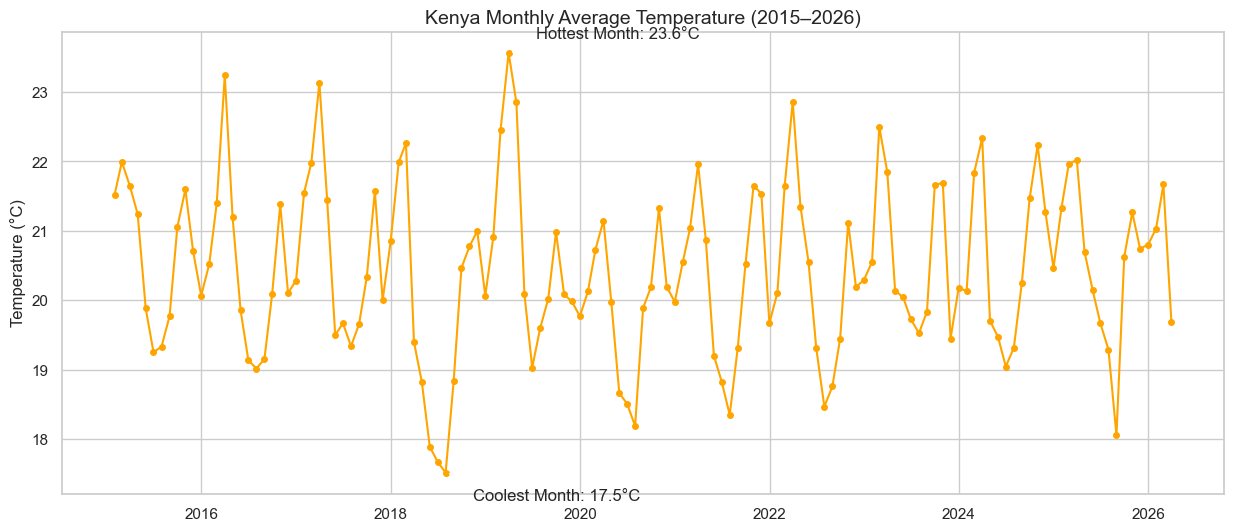

In [9]:
# 1. Resample to Monthly Averages - using only numeric columns
monthly_df = df_cleaned.resample('ME', on='Date').mean(numeric_only=True)

# 2. Setup the Plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', marker='o', linestyle='-', markersize=4)

# 3. Highlight the peaks and valleys
warmest = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest = monthly_df.loc[monthly_df['T2M'].idxmin()]

plt.annotate(f"Hottest Month: {warmest['T2M']:.1f}°C", xy=(warmest.name, warmest['T2M']),
             xytext=(20, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.annotate(f"Coolest Month: {coolest['T2M']:.1f}°C", xy=(coolest.name, coolest['T2M']),
             xytext=(20, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('Kenya Monthly Average Temperature (2015–2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.show()


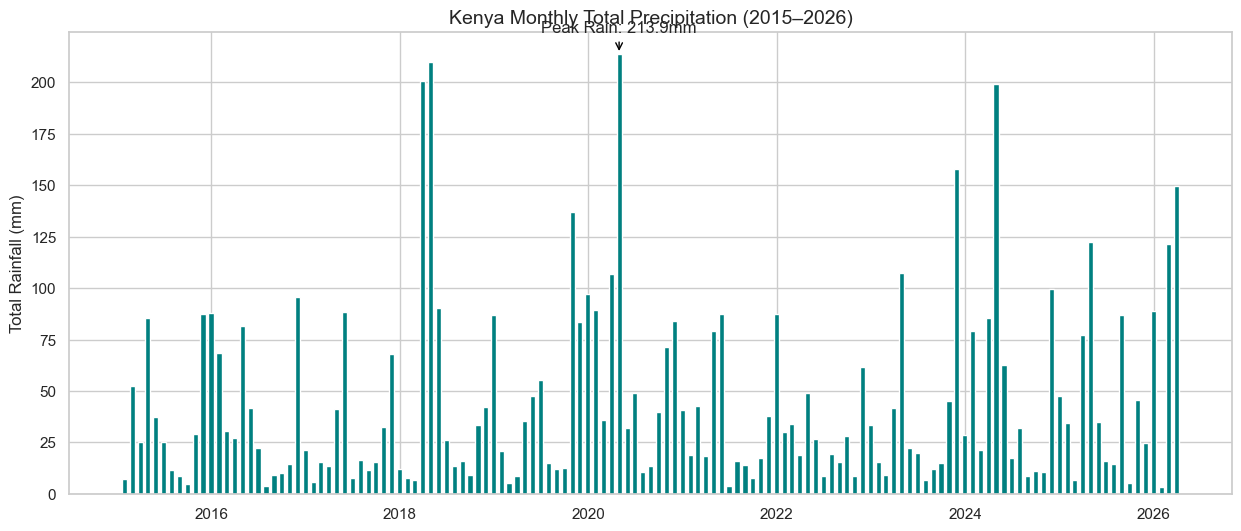

In [10]:
# 1. Resample for Total Monthly Rainfall
monthly_rain = df_cleaned.resample('ME', on='Date')['PRECTOTCORR'].sum()

# 2. Setup the Plot
plt.figure(figsize=(15, 6))
plt.bar(monthly_rain.index, monthly_rain, color='teal', width=20)

# 3. Find the peak rainy month
peak_rain = monthly_rain.idxmax()
peak_val = monthly_rain.max()

plt.annotate(f"Peak Rain: {peak_val:.1f}mm", xy=(peak_rain, peak_val),
             xytext=(0, 15), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Kenya Monthly Total Precipitation (2015–2026)', fontsize=14)
plt.ylabel('Total Rainfall (mm)')
plt.show()


### 5. Time Series Interpretation
- **Temperature Trends:** Kenya exhibits a clear and consistent cyclical temperature pattern across the years. Temperatures tend to peak early in the year and gradually decline toward mid-year before rising again. This repeating pattern indicates strong seasonal influence. There are no significant long-term spikes or downward trends, suggesting a relatively stable and consistently warm climate over the observed period.
- **Rainfall Patterns:** The rainfall data suggests a generally bimodal distribution, with two periods of increased precipitation within a year. These are commonly associated with the “Long Rains” (March–May) and the “Short Rains” (October–December). However, the pattern is not perfectly consistent across all years, as some periods show irregular or less pronounced peaks, indicating variability in seasonal rainfall.
- **Anomalies and Variabilty:** There are noticeable fluctuations in rainfall across different months and years, with some months experiencing significantly lower precipitation than others. While these dips may indicate short-term dry conditions, there is no strong evidence of prolonged drought periods in the dataset. Instead, the data reflects normal climatic variability rather than extreme anomalies.
